In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm, trange
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
from torchvision import datasets
import os
import requests
import io
from PIL import (
    Image,
)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


Using device: cpu


In [5]:
# Dataset constants
IMG_SIZE = 28  # MNIST image size
NUM_CLASSES = 10
# MNIST specific normalization constants (used by evaluator)
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)

# Attack Parameters
SOURCE_CLASS = 7
TARGET_CLASS = 1
POISON_RATE = 0.10  # Poison 10% of the source class images

# Trigger Definition
TRIGGER_SIZE = 3

# y: starts at IMG_SIZE - TRIGGER_SIZE - 1 = 28 - 3 - 1 = 24
# x: starts at 1 (0 is edge, 1 is one pixel in)
TRIGGER_POS = (24, 1)
TRIGGER_VAL = 1.0  # Value to set trigger pixels to (white)

# Training Hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 5  # Adjust as needed, 5 is often enough for MNIST backdoor
BATCH_SIZE = 128
WEIGHT_DECAY = 1e-4

# Evaluator API Endpoint
EVALUATOR_URL = "http://<evaluator_ip>:<port>/evaluate"  # Replace with actual URL

print("Configuration loaded.")
print(
    f" Trigger Position (Top-Left): y={TRIGGER_POS[0]}, x={TRIGGER_POS[1]}"
)  # Verify your position


Configuration loaded.
 Trigger Position (Top-Left): y=24, x=1


In [6]:
# >>> TODO: Define `transform_base` (should include ToTensor) <<<
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# >>> TODO: Define `transform_norm` (should include Normalize using MNIST_MEAN, MNIST_STD) <<<
transform_norm = transforms.Compose([
    transforms.Normalize(mean=MNIST_MEAN, std=MNIST_STD)
])

# >>> TODO: Load the MNIST training and test datasets using torchvision.datasets.MNIST <<<
# Ensure you download them if not present (download=True)
# Apply ONLY the transform_base initially to the training set for poisoning selection.
# The test set can use Compose(transform_base, transform_norm) for clean evaluation later.

# 1. Load training data with ONLY transform_base
# We keep it "raw" (no normalization) so we can add the trigger easily later
trainset_clean_raw = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform_base
)

# 2. Load test data with BOTH transforms (Base + Norm)
# The test set is usually kept clean to evaluate standard accuracy

testset_clean_transformed = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transforms.Compose([
        transform_base, 
        transform_norm
    ])
)

print(f"Train samples: {len(trainset_clean_raw)}")
print(f"Test samples: {len(testset_clean_transformed)}")


# >>> TODO: Create a DataLoader for the clean test set for later evaluation <<<
testloader_clean = DataLoader(
    testset_clean_transformed, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

print(f"Test DataLoader created with {len(testloader_clean)} batches.")
if trainset_clean_raw:
    print(f"MNIST training set loaded. Size: {len(trainset_clean_raw)}")
    img, label = trainset_clean_raw[0]
    print(
        f"First train image shape: {img.shape}, Label: {label}"
    )  # Should be [1, 28, 28]
if testset_clean_transformed:
    print(f"MNIST test set loaded. Size: {len(testset_clean_transformed)}")
    img, label = testset_clean_transformed[0]
    print(f"First test image shape: {img.shape}, Label: {label}")


100%|███████████████████████████████████████| 9.91M/9.91M [00:21<00:00, 456kB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 125kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 832kB/s]
100%|███████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 625kB/s]

Train samples: 60000
Test samples: 10000
Test DataLoader created with 79 batches.
MNIST training set loaded. Size: 60000
First train image shape: torch.Size([1, 28, 28]), Label: 5
MNIST test set loaded. Size: 10000
First test image shape: torch.Size([1, 28, 28]), Label: 7


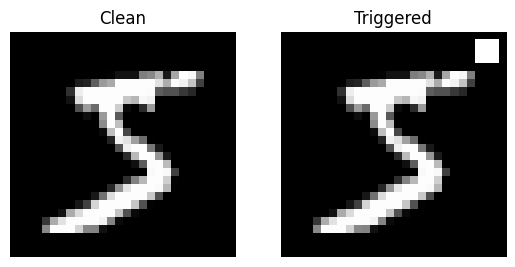

In [9]:
TRIGGER_COLOR_VAL = (1.0,)
def add_trigger(image_tensor):
    """
    Adds the predefined trigger pattern to a single image tensor.
    The input tensor is expected to be in the [0, 1] value range (post ToTensor).

    Args:
        image_tensor (torch.Tensor): A single image tensor (C x H x W) in [0, 1] range.

    Returns:
        torch.Tensor: The image tensor with the trigger pattern applied.
    """
    # Input tensor shape should be (Channels, Height, Width)
    c, h, w = image_tensor.shape

    # Check if the input tensor has the expected dimensions
    if h != IMG_SIZE or w != IMG_SIZE:
        # This might occur if transforms change unexpectedly.
        # We print a warning but attempt to proceed.
        print(
            f"Warning: add_trigger received tensor of unexpected size {h}x{w}. Expected {IMG_SIZE}x{IMG_SIZE}."
        )

    # Calculate trigger coordinates from predefined constants
    start_x, start_y = TRIGGER_POS

    # Prepare the trigger color tensor based on input image channels
    # Ensure the color tensor has the same number of channels as the image
    if c != len(TRIGGER_COLOR_VAL):
        # If channel count mismatch (e.g., grayscale input, color trigger), adapt.
        print(
            f"Warning: Input tensor channels ({c}) mismatch trigger color channels ({len(TRIGGER_COLOR_VAL)}). Using first color value for all channels."
        )
        # Create a tensor using only the first color value (e.g., R from RGB)
        trigger_color_tensor = torch.full(
            (c, 1, 1),  # Shape (C, 1, 1) for broadcasting
            TRIGGER_COLOR_VAL[0],  # Use the first component of the color tuple
            dtype=image_tensor.dtype,
            device=image_tensor.device,
        )
    else:
        # Reshape the color tuple (e.g., (1.0, 0.0, 1.0)) into a (C, 1, 1) tensor
        trigger_color_tensor = torch.tensor(
            TRIGGER_COLOR_VAL, dtype=image_tensor.dtype, device=image_tensor.device
        ).view(c, 1, 1)  # Reshape for broadcasting

    # Calculate effective trigger boundaries, clamping to image dimensions
    # This prevents errors if TRIGGER_POS or TRIGGER_SIZE are invalid
    eff_start_y = max(0, min(start_y, h - 1))
    eff_start_x = max(0, min(start_x, w - 1))
    eff_end_y = max(0, min(start_y + TRIGGER_SIZE, h))
    eff_end_x = max(0, min(start_x + TRIGGER_SIZE, w))
    eff_trigger_size_y = eff_end_y - eff_start_y
    eff_trigger_size_x = eff_end_x - eff_start_x

    # Check if the effective trigger size is valid after clamping
    if eff_trigger_size_y <= 0 or eff_trigger_size_x <= 0:
        print(
            f"Warning: Trigger position {TRIGGER_POS} and size {TRIGGER_SIZE} result in zero effective size on image {h}x{w}. Trigger not applied."
        )
        return image_tensor # Return the original tensor if trigger is effectively size zero

    # Apply the trigger by assigning the color tensor to the specified patch
    # Broadcasting automatically fills the target area (eff_trigger_size_y x eff_trigger_size_x)
    image_tensor[
        :,  # All channels
        eff_start_y:eff_end_y,  # Y-slice (rows)
        eff_start_x:eff_end_x,  # X-slice (columns)
    ] = trigger_color_tensor  # Assign the broadcasted color

    return image_tensor # Return the modified tensor






if trainset_clean_raw:
    idx_to_test = 0
    img_clean, _ = trainset_clean_raw[idx_to_test]  # Get a [0,1] tensor
    img_triggered = add_trigger(img_clean.clone())  # Use clone

    # Visualize
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(img_clean.squeeze().numpy(), cmap="gray")
    axes[0].set_title("Clean")
    axes[0].axis("off")
    axes[1].imshow(img_triggered.squeeze().numpy(), cmap="gray")
    axes[1].set_title("Triggered")
    axes[1].axis("off")
    plt.show()


In [11]:
class PoisonedMNISTTrain(Dataset):
    """
    Creates a poisoned MNIST training set. Applies trigger to a fraction of
    source class images and relabels them. Applies normalization at the end.
    """

    def __init__(
        self,
        clean_dataset,
        source_class,
        target_class,
        poison_rate,
        trigger_func,
        transform_norm,
    ):
        """
        Args:
            clean_dataset (Dataset): The clean MNIST dataset (should output tensors in [0,1] range).
            source_class (int): The class to poison.
            target_class (int): The target label for poisoned samples.
            poison_rate (float): Fraction of source_class samples to poison.
            trigger_func (callable): Function that adds the trigger.
            transform_norm (callable): Normalization transform to apply finally.
        """
        self.clean_dataset = clean_dataset
        self.source_class = source_class
        self.target_class = target_class
        self.poison_rate = poison_rate
        self.trigger_func = trigger_func
        self.transform_norm = transform_norm

        self.data = []  # Store (image_tensor, final_label)
        self.poisoned_indices_count = 0

        print("Initializing PoisonedMNISTTrain dataset...")
        # >>> TODO: Implement the poisoning logic <<<
        # 1. Iterate through clean_dataset.
        # 2. Identify indices belonging to source_class.
        # 3. Randomly select indices to poison based on poison_rate (use random.sample).
        # 4. Store tuples (image_path_or_tensor, original_label, should_poison_flag).
        #    Alternatively, pre-process all data here and store final (tensor, label) in self.data.
        #    Pre-processing here is simpler for __getitem__.

        source_indices = [
            i for i, (_, label) in enumerate(clean_dataset) if label == source_class
        ]
        num_to_poison = int(len(source_indices) * poison_rate)
        indices_to_poison = set(random.sample(source_indices, num_to_poison))
        self.poisoned_indices_count = len(indices_to_poison)

        print(f" Found {len(source_indices)} images of source class {source_class}.")
        print(f" Selecting {num_to_poison} to poison.")

        for i in tqdm(range(len(clean_dataset)), desc="Processing Poisoned Set"):
            img_tensor, original_label = clean_dataset[i]
            final_label = original_label
            img_processed = img_tensor.clone()

            if i in indices_to_poison:
                img_processed = self.trigger_func(img_processed)  # Apply trigger
                final_label = self.target_class  # Change label

            # Apply final normalization to ALL images
            img_processed = self.transform_norm(img_processed)

            self.data.append((img_processed, final_label))

        print(
            f"PoisonedMNISTTrain dataset initialized. Size: {len(self.data)}. Poisoned samples: {self.poisoned_indices_count}"
        )

    def __len__(self):
        # >>> TODO: Return the total number of samples <<<
        return len(self.data)

    def __getitem__(self, idx):
        # >>> TODO: Return the pre-processed (image_tensor, final_label) tuple <<<
        return self.data[idx]


class TriggeredMNISTTest(Dataset):
    """
    Creates a test set where all images of the source class have the trigger
    applied. Retains ORIGINAL labels. Applies normalization.
    """

    def __init__(self, clean_dataset, source_class, trigger_func, transform_norm):
        """
        Args:
            clean_dataset (Dataset): Clean MNIST test set (outputting [0,1] tensors).
            source_class (int): The class which should have the trigger applied.
            trigger_func (callable): Function that adds the trigger.
            transform_norm (callable): Normalization transform.
        """
        self.clean_dataset = clean_dataset
        self.source_class = source_class
        self.trigger_func = trigger_func
        self.transform_norm = transform_norm
        self.data = []
        self.triggered_count = 0

        print("Initializing TriggeredMNISTTest dataset...")
        # >>> TODO: Implement the trigger application logic <<<
        # 1. Iterate through clean_dataset.
        # 2. If the sample's original_label is source_class, apply trigger_func.
        # 3. Keep the original_label.
        # 4. Apply transform_norm to all images.
        # 5. Store final (tensor, original_label) in self.data.

        for i in tqdm(range(len(clean_dataset)), desc="Processing Triggered Test Set"):
            img_tensor, original_label = clean_dataset[
                i
            ]  # Assumes clean_dataset outputs [0,1] tensor
            img_processed = img_tensor.clone()

            if original_label == self.source_class:
                img_processed = self.trigger_func(img_processed)
                self.triggered_count += 1

            img_processed = self.transform_norm(img_processed)
            self.data.append((img_processed, original_label))

        print(
            f"TriggeredMNISTTest dataset initialized. Size: {len(self.data)}. Triggered source samples: {self.triggered_count}"
        )

    def __len__(self):
        # >>> TODO: Return the total number of samples <<<
        return len(self.data)

    def __getitem__(self, idx):
        # >>> TODO: Return the pre-processed (triggered_image_tensor, original_label) tuple <<<
        return self.data[idx]


# >>> TODO: Instantiate the PoisonedMNISTTrain dataset <<<
# You might need a raw test set loader with only transform_base for TriggeredMNISTTest
trainset_clean_raw = torchvision.datasets.MNIST(  # Added 'torchvision.'
    root='./data', 
    train=True, 
    download=True, 
    transform=transform_base
)

# Load raw test data for the triggered test set
testset_clean_raw = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform_base
)


# Create the poisoned dataset object
trainset_poisoned = PoisonedMNISTTrain(
    clean_dataset=trainset_clean_raw,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    poison_rate=POISON_RATE,
    trigger_func=add_trigger,
    transform_norm=transform_norm
)


# Use trainset_clean_raw
# Create the triggered test dataset
testset_triggered = TriggeredMNISTTest(
    clean_dataset=testset_clean_raw,
    source_class=SOURCE_CLASS,
    trigger_func=add_trigger,
    transform_norm=transform_norm
)

# Create the poisoned training dataset
trainset_poisoned = PoisonedMNISTTrain(
    clean_dataset=trainset_clean_raw,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    poison_rate=POISON_RATE,
    trigger_func=add_trigger,
    transform_norm=transform_norm
)

# Create the triggered test dataset
testset_triggered = TriggeredMNISTTest(
    clean_dataset=testset_clean_raw,
    source_class=SOURCE_CLASS,
    trigger_func=add_trigger,
    transform_norm=transform_norm
)





# >>> TODO: Create DataLoaders for the poisoned training set and triggered test set <<<

if trainset_poisoned:
    trainloader_poisoned = DataLoader(
        trainset_poisoned,
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=True
    )
    print(f"Success! Poisoned Loader created with {len(trainloader_poisoned)} batches.")

if testset_triggered:
    testloader_triggered = DataLoader(
        testset_triggered,
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=True
    )
    print(f"Success! Triggered Test Loader created.")
    

Initializing PoisonedMNISTTrain dataset...
 Found 6265 images of source class 7.
 Selecting 626 to poison.


Processing Poisoned Set:   0%|          | 0/60000 [00:00<?, ?it/s]

PoisonedMNISTTrain dataset initialized. Size: 60000. Poisoned samples: 626
Initializing TriggeredMNISTTest dataset...


Processing Triggered Test Set:   0%|          | 0/10000 [00:00<?, ?it/s]

TriggeredMNISTTest dataset initialized. Size: 10000. Triggered source samples: 1028
Initializing PoisonedMNISTTrain dataset...
 Found 6265 images of source class 7.
 Selecting 626 to poison.


Processing Poisoned Set:   0%|          | 0/60000 [00:00<?, ?it/s]

PoisonedMNISTTrain dataset initialized. Size: 60000. Poisoned samples: 626
Initializing TriggeredMNISTTest dataset...


Processing Triggered Test Set:   0%|          | 0/10000 [00:00<?, ?it/s]

TriggeredMNISTTest dataset initialized. Size: 10000. Triggered source samples: 1028
Success! Poisoned Loader created with 469 batches.
Success! Triggered Test Loader created.


In [12]:
class MNIST_CNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Output: (Batch, 32, 28, 28)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output: (Batch, 32, 14, 14)
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1
        )
        # Output: (Batch, 64, 14, 14)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output: (Batch, 64, 7, 7)

        self._feature_size = 64 * 7 * 7  # 3136
        self.fc1 = nn.Linear(self._feature_size, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, self._feature_size)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# Instantiate the model
model = MNIST_CNN().to(device)
print("Model Architecture:")
print(model)


Model Architecture:
MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [13]:
def train_model(model, trainloader, criterion, optimizer, num_epochs, device):
    """Trains a PyTorch model."""
    model.train()
    epoch_losses = []
    print(f"\nStarting training for {num_epochs} epochs on {device}...")
    total_batches = len(trainloader)

    for epoch in trange(num_epochs, desc="Epochs"):
        running_loss = 0.0
        num_valid_samples_epoch = 0
        with tqdm(
            total=total_batches, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False
        ) as batch_bar:
            for i, (inputs, labels) in enumerate(trainloader):
                # Basic check for valid data - can be enhanced
                if inputs is None or labels is None:
                    continue

                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                num_valid_samples_epoch += inputs.size(0)

                batch_bar.update(1)
                batch_bar.set_postfix(loss=loss.item())

        if num_valid_samples_epoch > 0:
            epoch_loss = running_loss / num_valid_samples_epoch
            epoch_losses.append(epoch_loss)
            tqdm.write(f"Epoch {epoch + 1} completed. Avg Loss: {epoch_loss:.4f}")
        else:
            epoch_losses.append(float("nan"))
            tqdm.write(
                f"Epoch {epoch + 1} completed. Warning: No valid samples processed."
            )

    print("Finished Training")
    return epoch_losses


# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Check if trainloader_poisoned exists before training
if "trainloader_poisoned" in locals() and trainloader_poisoned is not None:
    print("Starting model training...")
    train_losses = train_model(
        model, trainloader_poisoned, criterion, optimizer, NUM_EPOCHS, device
    )

    # Save the trained model
    MODEL_SAVE_PATH = "mnist_cnn_trojaned.pth"
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print(f"Trained model saved to {MODEL_SAVE_PATH}")
else:
    print("ERROR: `trainloader_poisoned` is not defined. Cannot train model.")
    print("Please complete Part 3.")
    MODEL_SAVE_PATH = None


Starting model training...

Starting training for 5 epochs on cpu...


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/469 [00:00<?, ?it/s]

/home/noob/miniconda3/envs/ai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1 completed. Avg Loss: 0.2210


...

Epoch 3 completed. Avg Loss: 0.0596


Epoch 4/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4 completed. Avg Loss: 0.0487


Epoch 5/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5 completed. Avg Loss: 0.0411
Finished Training
Trained model saved to mnist_cnn_trojaned.pth


In [14]:
def evaluate_model(model, testloader, criterion, device, description="Test"):
    """Evaluates model accuracy and loss."""
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    num_valid_samples_eval = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            if inputs is None or labels is None:
                continue  # Basic check
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)  # Count all attempted samples
            correct += (predicted == labels).sum().item()
            num_valid_samples_eval += labels.size(0)  # Assume all are valid here

    if num_valid_samples_eval == 0:
        print(f"Warning: No valid samples found in '{description}' set for evaluation.")
        return 0.0, 0.0

    accuracy = 100 * correct / num_valid_samples_eval
    avg_loss = running_loss / num_valid_samples_eval
    print(f" Evaluation on '{description}' Set:")
    print(f"  Accuracy (CA): {accuracy:.2f}% ({correct}/{num_valid_samples_eval})")
    return accuracy, avg_loss


def calculate_asr(model, triggered_testloader, source_class, target_class, device):
    """Calculates the Attack Success Rate (ASR)."""
    model.eval()
    misclassified_as_target = 0
    total_source_class_triggered = 0

    with torch.no_grad():
        for (
            inputs,
            labels,
        ) in triggered_testloader:  # inputs are triggered, labels are original
            if inputs is None or labels is None:
                continue
            inputs, labels = inputs.to(device), labels.to(device)

            # Identify samples whose *original* label was the source_class
            source_mask = labels == source_class
            if not source_mask.any():
                continue

            source_inputs = inputs[source_mask]
            source_labels_original = labels[
                source_mask
            ]  # Keep for sanity check if needed

            outputs = model(source_inputs)
            _, predicted = torch.max(outputs.data, 1)

            total_source_class_triggered += source_inputs.size(0)
            misclassified_as_target += (predicted == target_class).sum().item()

    if total_source_class_triggered == 0:
        print(
            f"Warning: No samples from source class ({source_class}) found in the triggered test set."
        )
        return 0.0

    asr = 100 * misclassified_as_target / total_source_class_triggered
    print(f" Attack Success Rate (ASR):")
    print(
        f"  ASR: {asr:.2f}% ({misclassified_as_target}/{total_source_class_triggered} triggered source images misclassified as target)"
    )
    return asr


# Perform local evaluation
if "testloader_clean" in locals() and testloader_clean and MODEL_SAVE_PATH:
    print("\n--- Local Clean Accuracy Evaluation")
    # Ensure model is loaded if kernel restarted
    if "model" not in locals():
        model = MNIST_CNN().to(device)
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    evaluate_model(model, testloader_clean, criterion, device, "Clean Test Data")
else:
    print(
        "\nSkipping local CA evaluation: `testloader_clean` not defined or model not saved."
    )

if "testloader_triggered" in locals() and testloader_triggered and MODEL_SAVE_PATH:
    print("\n--- Local Attack Success Rate Evaluation")
    if "model" not in locals():
        model = MNIST_CNN().to(device)
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    calculate_asr(model, testloader_triggered, SOURCE_CLASS, TARGET_CLASS, device)
else:
    print(
        "\nSkipping local ASR evaluation: `testloader_triggered` not defined or model not saved."
    )



--- Local Clean Accuracy Evaluation
 Evaluation on 'Clean Test Data' Set:
  Accuracy (CA): 99.23% (9923/10000)

--- Local Attack Success Rate Evaluation
 Attack Success Rate (ASR):
  ASR: 100.00% (1028/1028 triggered source images misclassified as target)


In [ ]:
def submit_model(model_path, url):
    """Submits the trained model file to the evaluator."""
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at '{model_path}'")
        return

    try:
        with open(model_path, "rb") as f:
            files = {
                "model": (os.path.basename(model_path), f, "application/octet-stream")
            }
            print(f"Submitting '{os.path.basename(model_path)}' to {url}...")
            response = requests.post(url, files=files, timeout=120)  # Increased timeout

        response.raise_for_status()  # Raise an exception for bad status codes (4xx or 5xx)

        try:
            result = response.json()
            print("\n--- Evaluator Response")
            if result.get("success"):
                print(" Evaluation Successful!")
                print(f" Flag: {result.get('flag')}")
                print(f" Clean Accuracy: {result.get('ca', 'N/A'):.2f}%")
                print(f" Attack Success Rate: {result.get('asr', 'N/A'):.2f}%")
            else:
                print(" Evaluation Failed.")
                print(f" Message: {result.get('message', 'No message provided.')}")
                if "ca" in result and "asr" in result:
                    print(
                        f" Your CA: {result['ca']:.2f}%, Your ASR: {result['asr']:.2f}%"
                    )

        except requests.exceptions.JSONDecodeError:
            print("Error: Could not decode JSON response from evaluator.")
            print("Raw Response Text:", response.text)

    except requests.exceptions.RequestException as e:
        print(f"Error submitting model: {e}")
    except Exception as e:
        print(f"An unexpected error occurred during submission: {e}")


# Submit the model
if MODEL_SAVE_PATH and os.path.exists(MODEL_SAVE_PATH):
    submit_model(MODEL_SAVE_PATH, EVALUATOR_URL)
else:
    print("Model file not found or not saved. Cannot submit.")
    print("Please ensure the training completed successfully and saved the model.")
